# 05. Fitting Comparison

`04_1`, `04_2`, `04_3`에서 저장한 파라미터를 같은 로그에 다시 적용해 비교한다.

- 대표 비교 표는 요청대로 `04_1/04_2/04_3`만 남기고 5개 지표만 사용한다.
- 학습 로그(`fit_logs`) loss 표와 held-out(`validation_logs`) loss 표는 각각 별도 셀로 분리한다.
- `raw/sine_5Hz`, `raw/sine_10Hz`는 command 대비 실측만 따로 확대해 비선형 구간을 본다.
- `step`, `ramp`, `S-curve`는 방향 전환/과도응답 중심으로 자동 확대해서 twin-실측 차이를 확인한다.


In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json
import re
import sys
import warnings

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "code" / "single_motor_twin.py").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("code/single_motor_twin.py를 찾을 수 없습니다.")

CODE_DIR = PROJECT_ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from metrics import (
    ramp_response_metrics,
    sine_response_metrics,
    step_response_metrics,
    trajectory_metrics,
)
from single_motor_twin import MotorParams, simulate_motor
from wmx_log_utils import load_wmx_log

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", message="WMX 샘플 간격이 일정하지 않습니다.*")


In [2]:
PARAMETER_SPECS = [
    {
        "label": "04_1",
        "json_path": PROJECT_ROOT / "fitted_motor_params.json",
        "origin_notebook": PROJECT_ROOT / "notebooks" / "04_1_parameter_fitting.ipynb",
        "fitting_method": "원본 1 ms 해상도 Step/Ramp/Multi-sine 전체 refinement",
    },
    {
        "label": "04_2",
        "json_path": PROJECT_ROOT / "fitted_motor_params_dec.json",
        "origin_notebook": PROJECT_ROOT / "notebooks" / "04_2_parameter_fitting_dec.ipynb",
        "fitting_method": "adaptive decimation을 포함한 전체 refinement",
    },
    {
        "label": "04_3",
        "json_path": PROJECT_ROOT / "fitted_motor_params_init.json",
        "origin_notebook": PROJECT_ROOT / "notebooks" / "04_3_parameter_fitting_init.ipynb",
        "fitting_method": "초기 버전 full-resolution fitting 결과",
    },
]

CSV_DATA_DIR = Path("/mnt/c/Users/kate/Downloads/csv_data")
RAW_DATA_DIR = CSV_DATA_DIR / "raw"

DEG_TO_RAD = np.pi / 180.0
RATED_TORQUE_NM = 0.16
LOG_OPTIONS = {
    "cycle_period_s": 1.0e-3,
    "position_scale": DEG_TO_RAD,
    "velocity_scale": DEG_TO_RAD,
    "torque_scale": RATED_TORQUE_NM / 100.0,
}
SIGNAL_KEYS = (
    "command_position",
    "feedback_position",
    "feedback_velocity",
    "feedback_torque",
)
INITIAL_WINDOW_S = 0.02

REPRESENTATIVE_METRIC_COLUMNS = [
    "heldout_position_nrmse_mean",
    "heldout_velocity_nrmse_mean",
    "step_settling_abs_error_s",
    "ramp_torque_bias_abs",
    "sine_phase_abs_error_deg_mean",
]
REPRESENTATIVE_METRIC_RENAME = {
    "heldout_position_nrmse_mean": "heldout_position_nrmse_mean",
    "heldout_velocity_nrmse_mean": "heldout_velocity_nrmse_mean",
    "step_settling_abs_error_s": "step_settling_abs_error_s",
    "ramp_torque_bias_abs": "ramp_torque_bias_abs",
    "sine_phase_abs_error_deg_mean": "sine_phase_abs_error_deg_mean",
}

MODEL_COLORS = {
    "04_1": "#1f77b4",
    "04_2": "#ff7f0e",
    "04_3": "#2ca02c",
}

ZOOM_WINDOW_SECONDS = {
    "step": (0.05, 0.45),
    "ramp": (0.35, 0.35),
    "validation": (0.35, 0.35),
}

RAW_SINE_SPECS = [
    {"label": "raw_sine_5hz", "path": RAW_DATA_DIR / "sine_5Hz.csv", "frequency_hz": 5.0},
    {"label": "raw_sine_10hz", "path": RAW_DATA_DIR / "sine_10Hz.csv", "frequency_hz": 10.0},
]

ZOOM_DATASETS = [
    "step",
    "ramp",
    "scurve_validation_1",
    "scurve_validation_2",
]


def load_parameter_bundle(spec):
    payload = json.loads(spec["json_path"].read_text(encoding="utf-8"))
    return {
        **spec,
        "payload": payload,
        "motor_params": MotorParams(**payload["motor_params"]),
    }


def align_log(data, profile):
    raw_time = np.asarray(data["time"], dtype=np.float64)
    dt = float(np.median(np.diff(raw_time)))
    count = int(np.floor((raw_time[-1] - raw_time[0]) / dt + 1.0e-9)) + 1
    time_axis = np.arange(count, dtype=np.float64) * dt
    result = {
        key: np.interp(time_axis, raw_time - raw_time[0], data[key])
        for key in SIGNAL_KEYS
    }
    initial_count = min(count, max(3, int(round(INITIAL_WINDOW_S / dt))))
    position_origin = float(np.median(result["feedback_position"][:initial_count]))
    initial_velocity = float(np.median(result["feedback_velocity"][:initial_count]))
    result["command_position"] -= position_origin
    result["feedback_position"] -= position_origin
    result.update(
        {
            "profile": profile,
            "source": data["source"],
            "time": time_axis,
            "dt": dt,
            "source_dt": dt,
            "position_origin": position_origin,
            "initial_position": float(result["feedback_position"][0]),
            "initial_velocity": initial_velocity,
        }
    )
    return result


def infer_profile_kind(name):
    lowered = name.lower()
    if "step" in lowered:
        return "step"
    if "ramp" in lowered:
        return "ramp"
    if "sine" in lowered:
        return "sine"
    if "scurve" in lowered:
        return "validation"
    return "other"


def infer_frequency_hz(name):
    match = re.search(r"sine_(\d+(?:\.\d+)?)hz", name.lower())
    return float(match.group(1)) if match else None


def dedupe_sorted_indices(indices, min_gap):
    if not indices:
        return []
    result = [int(sorted(indices)[0])]
    for value in sorted(indices)[1:]:
        if int(value) - result[-1] >= int(min_gap):
            result.append(int(value))
    return result


def slice_bounds(time_axis, center_idx, before_s, after_s):
    center_idx = int(np.clip(center_idx, 0, len(time_axis) - 1))
    center_time = float(time_axis[center_idx])
    start_idx = int(np.searchsorted(time_axis, center_time - before_s, side="left"))
    stop_idx = int(np.searchsorted(time_axis, center_time + after_s, side="right"))
    start_idx = max(0, start_idx)
    stop_idx = min(len(time_axis), max(start_idx + 2, stop_idx))
    return start_idx, stop_idx


def summary_value(group, column):
    series = group[column].dropna()
    return float(series.mean()) if not series.empty else np.nan


def choose_raw_sine_center(data, frequency_hz):
    command = np.asarray(data["command_position"], dtype=np.float64)
    feedback = np.asarray(data["feedback_position"], dtype=np.float64)
    dt = float(data["dt"])
    velocity = np.gradient(command, dt)
    threshold = max(float(np.percentile(np.abs(velocity), 85.0)) * 0.10, 1.0e-6)
    sign = np.sign(velocity)
    sign[np.abs(velocity) < threshold] = 0.0
    candidates = list(np.flatnonzero(np.diff(sign) != 0) + 1)
    if not candidates:
        candidates = [int(np.argmax(np.abs(np.gradient(velocity, dt))))]
    neighborhood = max(5, int(round((0.20 / frequency_hz) / dt)))
    following_error = np.abs(command - feedback)
    best_idx = int(candidates[0])
    best_score = -np.inf
    for idx in candidates:
        start = max(0, int(idx) - neighborhood)
        stop = min(len(command), int(idx) + neighborhood)
        score = float(np.mean(following_error[start:stop]))
        if score > best_score:
            best_idx = int(idx)
            best_score = score
    return best_idx


def detect_turn_candidates(data):
    kind = infer_profile_kind(data["profile"])
    command = np.asarray(data["command_position"], dtype=np.float64)
    dt = float(data["dt"])
    if kind == "step":
        return [int(np.argmax(np.abs(np.diff(command)))) + 1]

    velocity = np.gradient(command, dt)
    acceleration = np.gradient(velocity, dt)
    threshold = max(float(np.percentile(np.abs(velocity), 85.0)) * 0.10, 1.0e-6)
    sign = np.sign(velocity)
    sign[np.abs(velocity) < threshold] = 0.0
    sign_changes = list(np.flatnonzero(np.diff(sign) != 0) + 1)
    accel_peaks = list(np.argsort(np.abs(acceleration))[-10:])
    min_gap = max(5, int(round(0.12 / dt)))
    candidates = dedupe_sorted_indices(sign_changes + accel_peaks, min_gap=min_gap)
    if not candidates:
        candidates = [int(np.argmax(np.abs(acceleration)))]
    return candidates


def zoom_window_score(dataset_name, center_idx, before_s, after_s):
    measurement = shared_measurements[dataset_name]
    time_axis = measurement["time"]
    start_idx, stop_idx = slice_bounds(time_axis, center_idx, before_s, after_s)
    score = 0.0
    for bundle in bundles:
        simulation = simulations[bundle["label"]][dataset_name]
        position_error = simulation["feedback_position"][start_idx:stop_idx] - measurement["feedback_position"][start_idx:stop_idx]
        velocity_error = simulation["feedback_velocity"][start_idx:stop_idx] - measurement["feedback_velocity"][start_idx:stop_idx]
        score += float(np.mean(np.abs(position_error)))
        score += 0.15 * float(np.mean(np.abs(velocity_error)))
    return score, start_idx, stop_idx


def pick_zoom_window(dataset_name):
    measurement = shared_measurements[dataset_name]
    kind = infer_profile_kind(dataset_name)
    before_s, after_s = ZOOM_WINDOW_SECONDS["validation" if kind == "validation" else kind]
    candidates = detect_turn_candidates(measurement)
    best = None
    for center_idx in candidates:
        score, start_idx, stop_idx = zoom_window_score(
            dataset_name,
            center_idx,
            before_s,
            after_s,
        )
        item = {
            "dataset": dataset_name,
            "kind": kind,
            "center_idx": int(center_idx),
            "center_time_s": float(measurement["time"][int(center_idx)]),
            "start_idx": int(start_idx),
            "stop_idx": int(stop_idx),
            "start_time_s": float(measurement["time"][int(start_idx)]),
            "stop_time_s": float(measurement["time"][int(stop_idx) - 1]),
            "score": float(score),
        }
        if best is None or item["score"] > best["score"]:
            best = item
    return best


In [3]:
bundles = [load_parameter_bundle(spec) for spec in PARAMETER_SPECS]

all_dataset_names = []
for bundle in bundles:
    all_dataset_names.extend(bundle["payload"]["fit_logs"].keys())
    all_dataset_names.extend(bundle["payload"]["validation_logs"].keys())
all_dataset_names = list(dict.fromkeys(all_dataset_names))

preferred_paths = {}
for dataset_name in all_dataset_names:
    candidates = []
    for bundle in bundles:
        for group_name in ("fit_logs", "validation_logs"):
            if dataset_name in bundle["payload"][group_name]:
                candidates.append(Path(bundle["payload"][group_name][dataset_name]))
    preferred_paths[dataset_name] = next((path for path in candidates if path.exists()), candidates[0])

shared_measurements = {}
missing_measurements = []
for dataset_name, dataset_path in preferred_paths.items():
    if not dataset_path.exists():
        missing_measurements.append((dataset_name, str(dataset_path)))
        continue
    measurement = load_wmx_log(dataset_path, **LOG_OPTIONS)
    shared_measurements[dataset_name] = align_log(measurement, dataset_name)

if missing_measurements:
    print("비교에서 제외된 로그")
    for dataset_name, raw_path in missing_measurements:
        print(f"- {dataset_name}: {raw_path}")

fit_dataset_names = sorted(
    name
    for name in all_dataset_names
    if infer_profile_kind(name) != "validation" and name in shared_measurements
)
heldout_dataset_names = sorted(
    name
    for name in all_dataset_names
    if infer_profile_kind(name) == "validation" and name in shared_measurements
)

simulations = {}
metric_rows = []
errors = []

for bundle in bundles:
    parameter_label = bundle["label"]
    simulations[parameter_label] = {}
    for dataset_name, measurement in shared_measurements.items():
        try:
            simulation = simulate_motor(
                measurement["command_position"],
                measurement["dt"],
                bundle["motor_params"],
                device="cpu",
                use_viewer=False,
                initial_position=measurement["initial_position"],
                initial_velocity=measurement["initial_velocity"],
            )
        except Exception as exc:
            errors.append(
                {
                    "parameter_label": parameter_label,
                    "dataset": dataset_name,
                    "error": repr(exc),
                }
            )
            continue

        simulations[parameter_label][dataset_name] = simulation
        row = {
            "parameter_label": parameter_label,
            "dataset": dataset_name,
            "kind": infer_profile_kind(dataset_name),
            "frequency_hz": infer_frequency_hz(dataset_name),
        }
        row.update(trajectory_metrics(measurement, simulation))

        if row["kind"] == "step":
            row.update(step_response_metrics(measurement, simulation))
        elif row["kind"] == "ramp":
            row.update(ramp_response_metrics(measurement, simulation))
        elif row["kind"] == "sine" and row["frequency_hz"] is not None:
            row.update(sine_response_metrics(measurement, simulation, row["frequency_hz"]))

        metric_rows.append(row)

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["dataset", "parameter_label"])
    .reset_index(drop=True)
)
errors_df = pd.DataFrame(errors)

if not errors_df.empty:
    display(errors_df)

print("fit datasets:", fit_dataset_names)
print("held-out datasets:", heldout_dataset_names)
print("metrics rows:", len(metrics_df))


Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, CUDA driver not available (NVRTC compilation available)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/ireh21/.cache/warp/1.16.0
Module validate_and_correct_inertia_kernel_5e18b3cd 2f0edb1 load on device 'cpu' took 13.14 ms  (cached)
Module newton._src.geometry.bvh 24ddd6d load on device 'cpu' took 2.96 ms  (cached)
Module newton._src.sim.articulation 57145c7 load on device 'cpu' took 3.19 ms  (cached)
Module newton._src.solvers.featherstone.kernels 4399e75 load on device 'cpu' took 4.20 ms  (cached)
fit datasets: ['ramp', 'sine_0.1hz', 'sine_0.2hz', 'sine_0.5hz', 'sine_1hz', 'sine_2hz', 'step']
held-out datasets: ['scurve_validation_1', 'scurve_validation_2']
metrics rows: 27


## 대표 비교 표

대표 비교는 딱 5개만 남긴다.

- held-out S-curve 평균 `position_nrmse`
- held-out S-curve 평균 `velocity_nrmse`
- `step` 정착시간 절대오차
- `ramp` 평균 토크 bias 절대값
- sine fit 로그 평균 위상오차


In [4]:
representative_rows = []
for parameter_label, group in metrics_df.groupby("parameter_label", sort=False):
    heldout = group.loc[group["kind"] == "validation"]
    step = group.loc[group["kind"] == "step"]
    ramp = group.loc[group["kind"] == "ramp"]
    sine = group.loc[group["kind"] == "sine"]
    representative_rows.append(
        {
            "parameter_label": parameter_label,
            "heldout_position_nrmse_mean": summary_value(heldout, "position_nrmse"),
            "heldout_velocity_nrmse_mean": summary_value(heldout, "velocity_nrmse"),
            "step_settling_abs_error_s": summary_value(step, "settling_abs_error_s"),
            "ramp_torque_bias_abs": summary_value(ramp, "torque_bias_abs"),
            "sine_phase_abs_error_deg_mean": summary_value(sine, "phase_abs_error_deg"),
        }
    )

representative_metrics_df = (
    pd.DataFrame(representative_rows)
    .set_index("parameter_label")
    .loc[[bundle["label"] for bundle in bundles], REPRESENTATIVE_METRIC_COLUMNS]
    .rename(columns=REPRESENTATIVE_METRIC_RENAME)
)
display(representative_metrics_df.round(6))


,heldout_position_nrmse_mean,heldout_velocity_nrmse_mean,step_settling_abs_error_s,ramp_torque_bias_abs,sine_phase_abs_error_deg_mean
parameter_label,,,,,
04_1,0.000907,0.105966,0.052,0.000116,1.946675
04_2,0.004468,0.105819,0.052,0.000025,1.455392
04_3,0.004602,0.105689,0.052,0.000132,2.107744


## 피팅 파라미터 비교

아래 표는 실제로 비교에 쓰인 `04_1`, `04_2`, `04_3`의 주요 피팅 파라미터만 정리한 것이다.


In [5]:
parameter_table = pd.DataFrame(
    [
        {
            "parameter_label": bundle["label"],
            "origin_notebook": bundle["origin_notebook"].name,
            "json_file": bundle["json_path"].name,
            "delay_steps": bundle["motor_params"].delay_steps,
            "inertia": bundle["motor_params"].inertia,
            "viscous": bundle["motor_params"].viscous,
            "coulomb": bundle["motor_params"].coulomb,
            "kp": bundle["motor_params"].kp,
            "kd": bundle["motor_params"].kd,
            "torque_response_time_constant": bundle["motor_params"].torque_response_time_constant,
        }
        for bundle in bundles
    ]
)
display(parameter_table.round(8))


,parameter_label,origin_notebook,json_file,delay_steps,inertia,viscous,coulomb,kp,kd,torque_response_time_constant
0,04_1,04_1_parameter_fitting.ipynb,fitted_motor_params.json,6,0.000008,0.000165,0.003971,1.783442,0.034893,0.002462
1,04_2,04_2_parameter_fitting_dec.ipynb,fitted_motor_params_dec.json,0,0.000087,0.000051,0.003932,0.763473,0.025953,0.006091
2,04_3,04_3_parameter_fitting_init.ipynb,fitted_motor_params_init.json,0,0.000224,0.000010,0.003433,0.233034,0.007724,0.000000


## 학습 로그 기준 Loss 요약

`fit_logs`로 저장된 loss를 그대로 비교한다.


In [6]:
fit_loss_summary = pd.DataFrame(
    [
        {
            "parameter_label": bundle["label"],
            **bundle["payload"]["fit_losses"],
        }
        for bundle in bundles
    ]
).set_index("parameter_label")
fit_loss_summary = fit_loss_summary.loc[[bundle["label"] for bundle in bundles], ["position", "velocity", "torque", "total"]]
display(fit_loss_summary.round(6))


,position,velocity,torque,total
parameter_label,,,,
04_1,0.241997,4.627083,1.288011,1.913105
04_2,0.423258,4.905698,4.920562,3.186256
04_3,0.550906,8.008795,0.003474,2.677200


## Held-out 기준 Loss 요약

`validation_logs`의 S-curve held-out loss만 따로 본다.


In [7]:
heldout_loss_summary = pd.DataFrame(
    [
        {
            "parameter_label": bundle["label"],
            **bundle["payload"]["validation_losses"],
        }
        for bundle in bundles
    ]
).set_index("parameter_label")
heldout_loss_summary = heldout_loss_summary.loc[[bundle["label"] for bundle in bundles], ["position", "velocity", "torque", "total"]]
display(heldout_loss_summary.round(6))


,position,velocity,torque,total
parameter_label,,,,
04_1,0.065575,1.636338,0.170089,0.554198
04_2,1.593155,1.633148,0.093132,1.167313
04_3,1.690070,1.629089,0.000079,1.179369


## Raw Sine 비선형 구간

`raw/sine_5Hz`, `raw/sine_10Hz`에서 command 속도가 0을 지나며 방향이 바뀌는 구간만 자동으로 골라 확대한다.
아래 그래프는 twin이 아니라 raw command 대비 실측 응답이다.


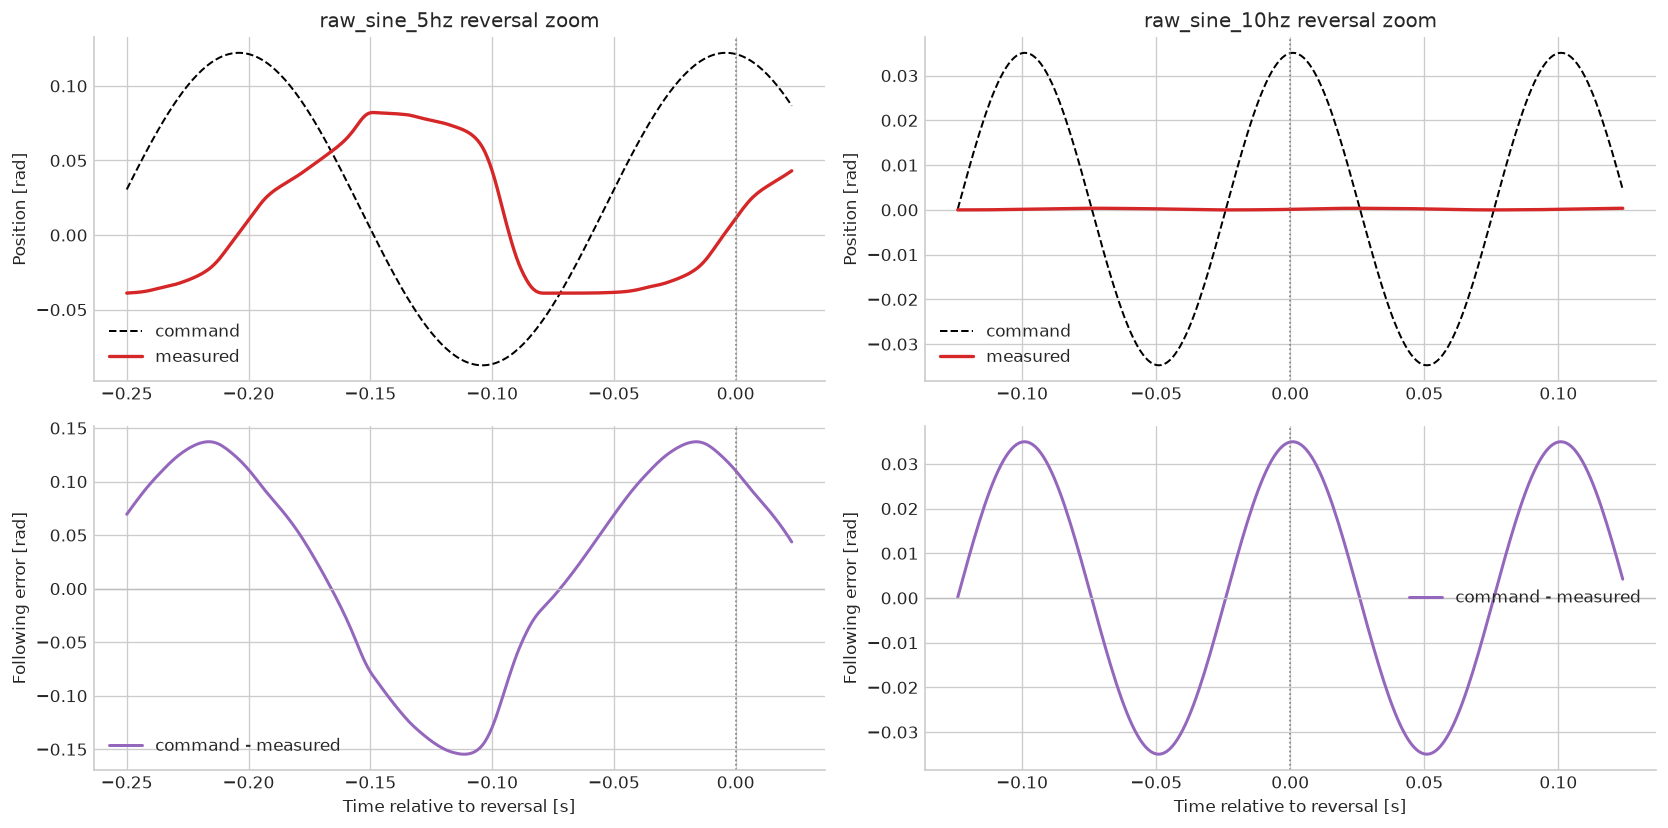

In [8]:
raw_sine_segments = []
for spec in RAW_SINE_SPECS:
    if not spec["path"].exists():
        continue
    raw_data = align_log(load_wmx_log(spec["path"], **LOG_OPTIONS), spec["label"])
    center_idx = choose_raw_sine_center(raw_data, spec["frequency_hz"])
    half_window_s = 1.25 / spec["frequency_hz"]
    start_idx, stop_idx = slice_bounds(raw_data["time"], center_idx, half_window_s, half_window_s)
    raw_sine_segments.append(
        {
            "label": spec["label"],
            "frequency_hz": spec["frequency_hz"],
            "data": raw_data,
            "center_idx": center_idx,
            "start_idx": start_idx,
            "stop_idx": stop_idx,
        }
    )

if not raw_sine_segments:
    print("raw sine 파일을 찾지 못했습니다.")
else:
    fig, axes = plt.subplots(2, len(raw_sine_segments), figsize=(7 * len(raw_sine_segments), 7), sharex=False)
    if len(raw_sine_segments) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for column, segment in enumerate(raw_sine_segments):
        data = segment["data"]
        start_idx = segment["start_idx"]
        stop_idx = segment["stop_idx"]
        center_time = float(data["time"][segment["center_idx"]])
        time_rel = data["time"][start_idx:stop_idx] - center_time
        command = data["command_position"][start_idx:stop_idx]
        feedback = data["feedback_position"][start_idx:stop_idx]
        following_error = command - feedback

        axes[0, column].plot(time_rel, command, color="black", linestyle="--", linewidth=1.2, label="command")
        axes[0, column].plot(time_rel, feedback, color="#d62728", linewidth=2.0, label="measured")
        axes[0, column].axvline(0.0, color="0.5", linestyle=":", linewidth=1.0)
        axes[0, column].set_title(f"{segment['label']} reversal zoom")
        axes[0, column].set_ylabel("Position [rad]")
        axes[0, column].legend(loc="best")

        axes[1, column].plot(time_rel, following_error, color="#9467bd", linewidth=1.8, label="command - measured")
        axes[1, column].axhline(0.0, color="0.75", linewidth=0.8)
        axes[1, column].axvline(0.0, color="0.5", linestyle=":", linewidth=1.0)
        axes[1, column].set_ylabel("Following error [rad]")
        axes[1, column].set_xlabel("Time relative to reversal [s]")
        axes[1, column].legend(loc="best")

    plt.tight_layout()
    plt.show()


## 방향 전환/과도응답 확대

직선 구간은 셋 다 대부분 잘 따라가므로, 여기서는 `step`, `ramp`, `scurve_validation_1`, `scurve_validation_2`의
방향 전환 또는 과도응답 구간만 확대한다. 확대 중심은 command 변화와 모델-실측 오차가 큰 지점을 자동으로 고른다.


,dataset,kind,center_time_s,start_time_s,stop_time_s,score
0,step,step,7.505,7.455,7.955,2.1909
1,ramp,ramp,12.061,11.712,12.410,0.3544
2,scurve_validation_1,validation,4.772,4.422,5.122,0.3507
3,scurve_validation_2,validation,10.604,10.254,10.954,0.3504


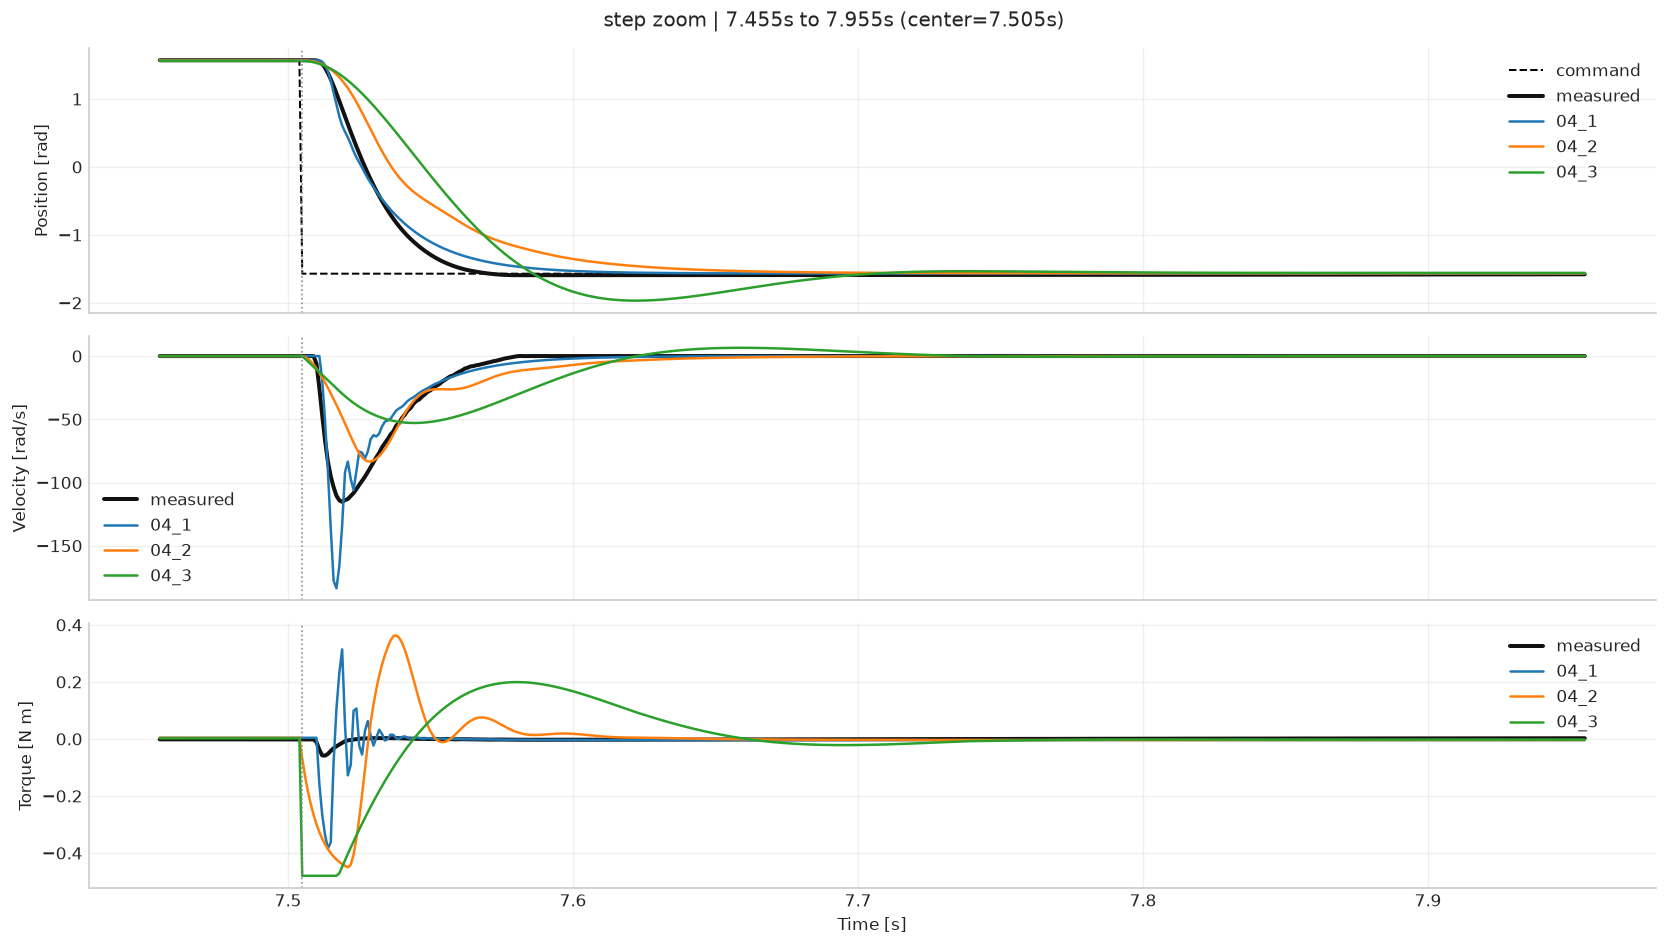

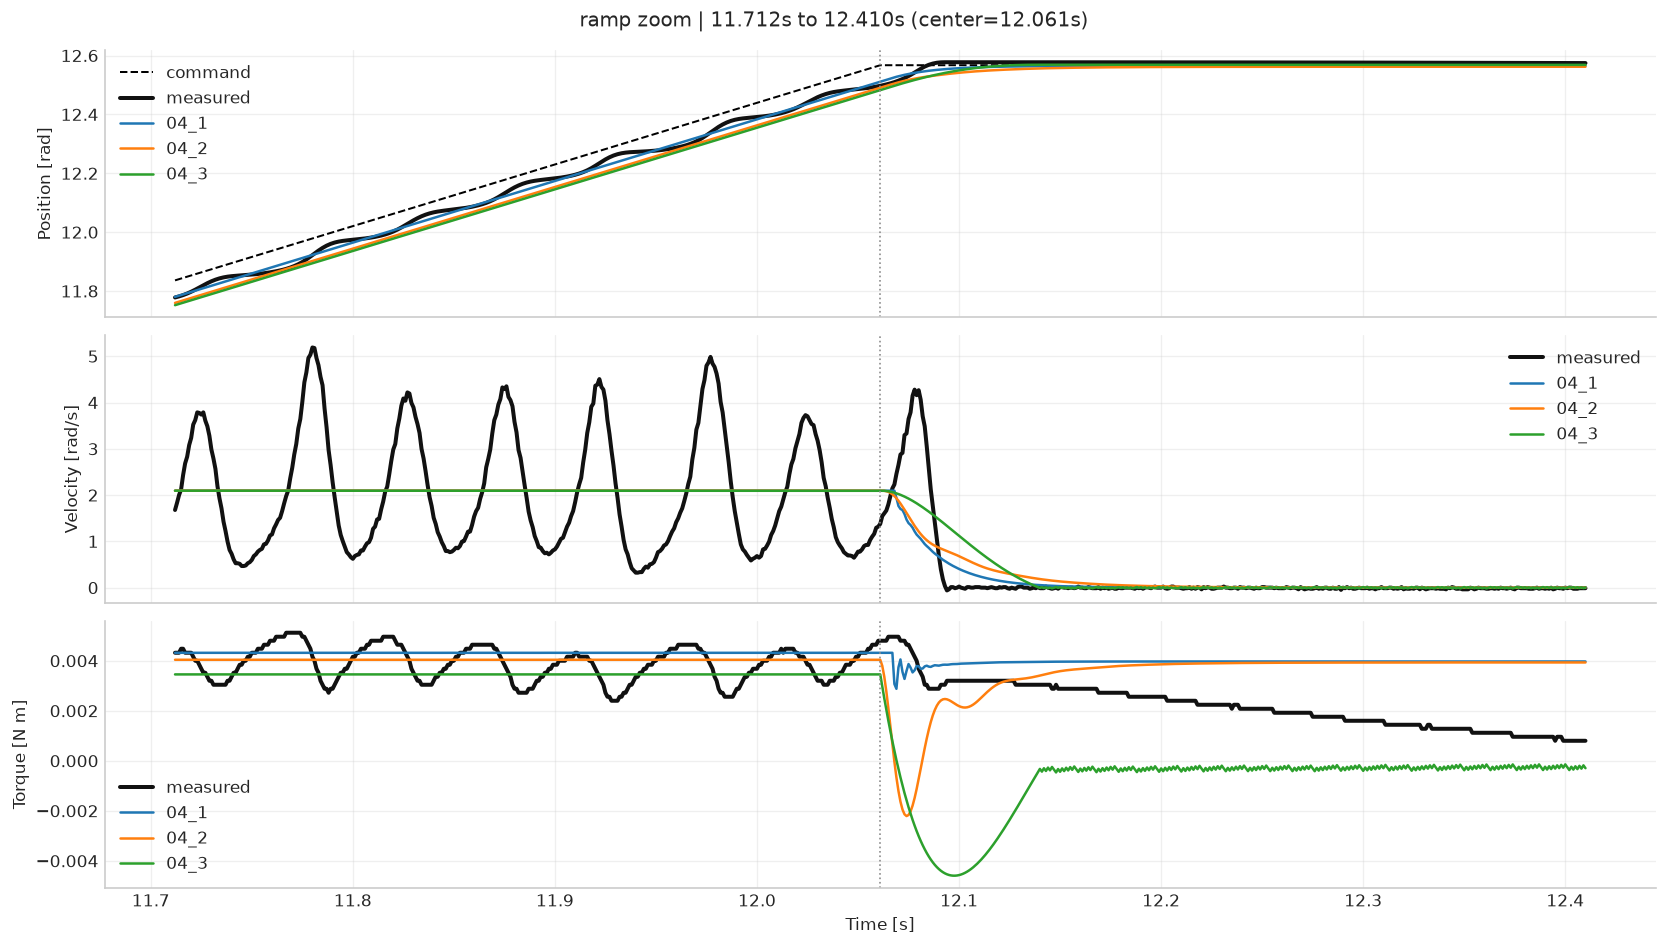

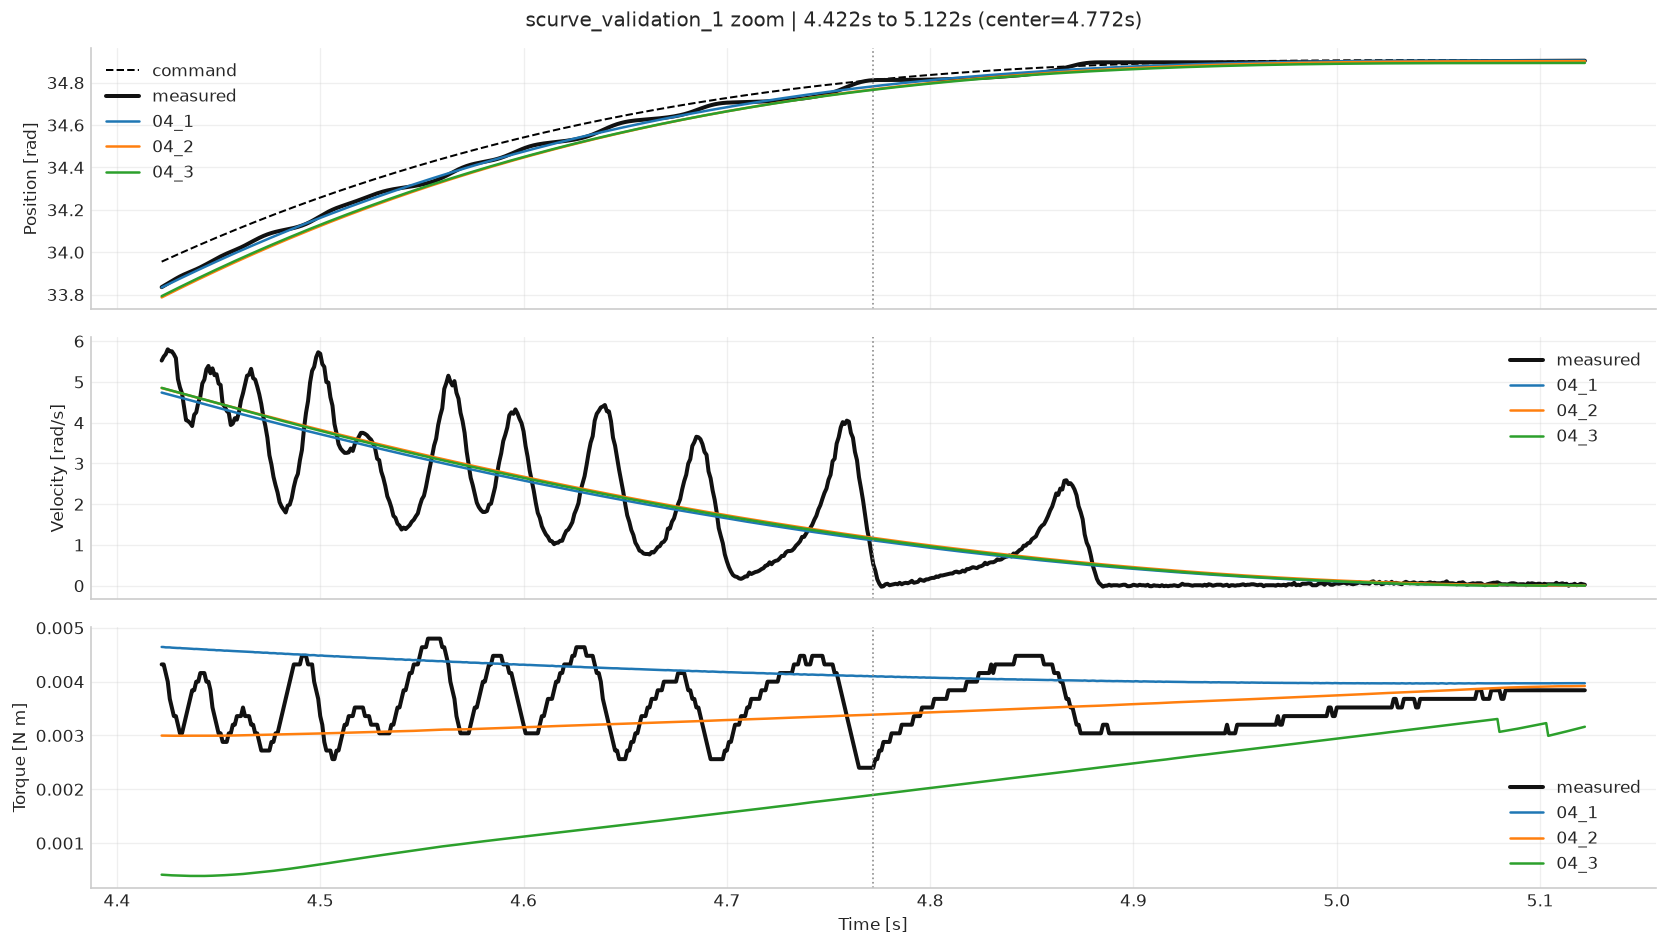

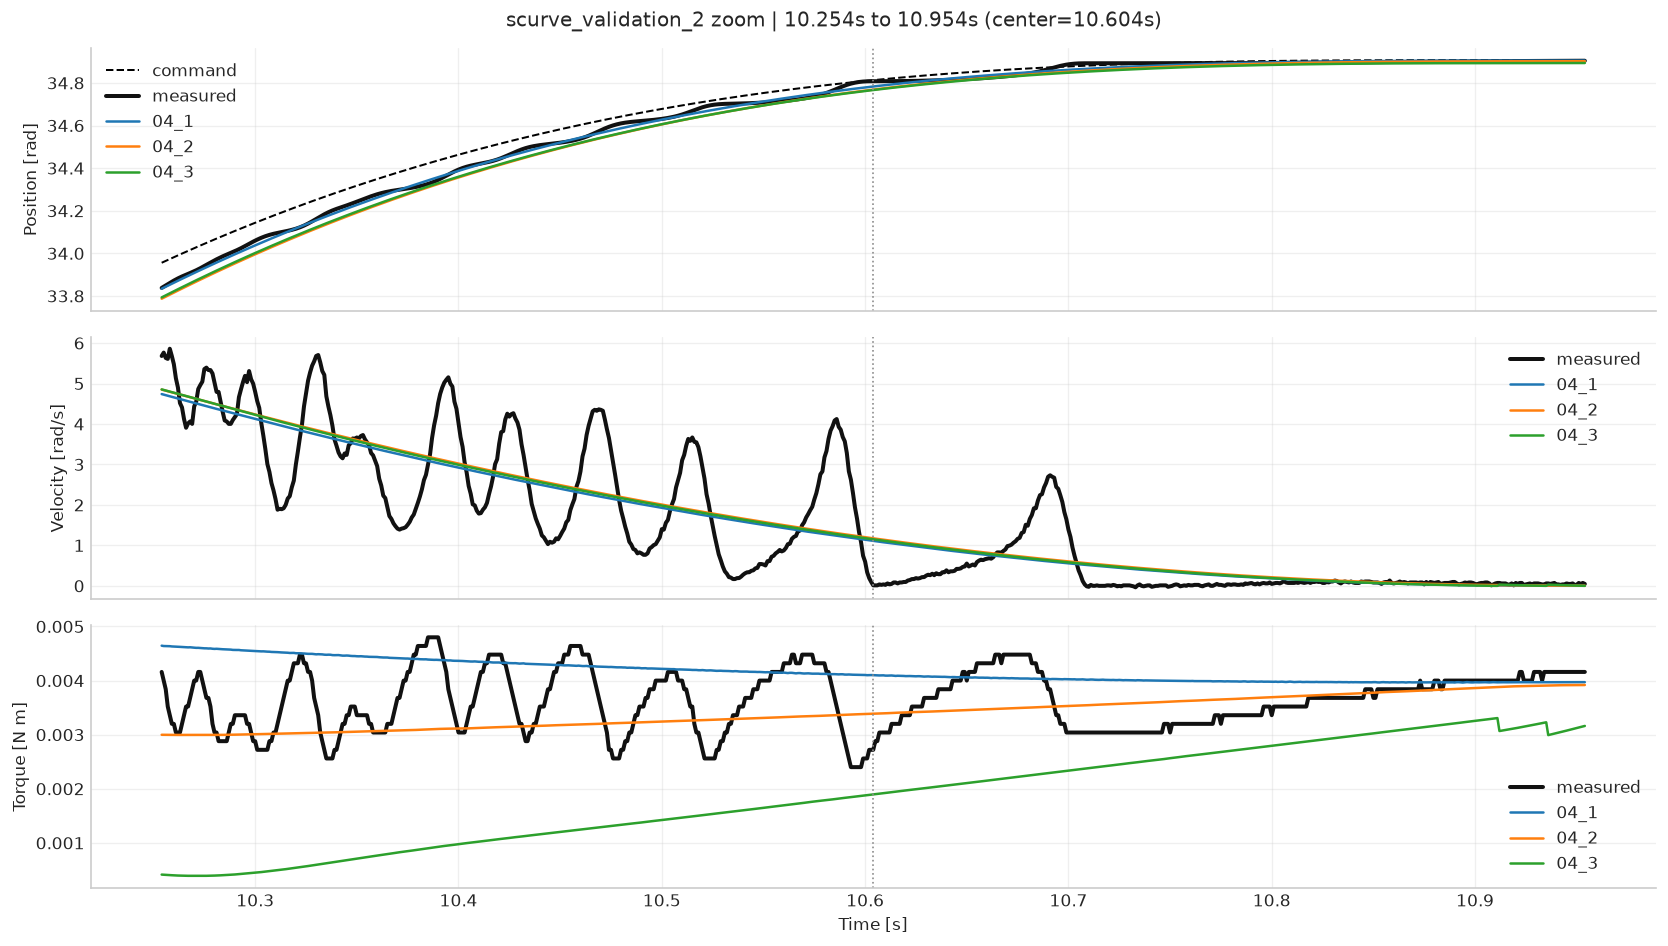

In [9]:
zoom_windows = [pick_zoom_window(dataset_name) for dataset_name in ZOOM_DATASETS if dataset_name in shared_measurements]
zoom_windows_df = pd.DataFrame(zoom_windows)[
    ["dataset", "kind", "center_time_s", "start_time_s", "stop_time_s", "score"]
]
display(zoom_windows_df.round(4))

zoom_plot_signals = [
    ("feedback_position", "Position [rad]"),
    ("feedback_velocity", "Velocity [rad/s]"),
    ("feedback_torque", "Torque [N m]"),
]

for window in zoom_windows:
    dataset_name = window["dataset"]
    measurement = shared_measurements[dataset_name]
    start_idx = window["start_idx"]
    stop_idx = window["stop_idx"]
    time_axis = measurement["time"][start_idx:stop_idx]

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(
        f"{dataset_name} zoom | {window['start_time_s']:.3f}s to {window['stop_time_s']:.3f}s "
        f"(center={window['center_time_s']:.3f}s)"
    )

    for axis, (signal_key, ylabel) in zip(axes, zoom_plot_signals):
        if signal_key == "feedback_position":
            axis.plot(
                time_axis,
                measurement["command_position"][start_idx:stop_idx],
                color="black",
                linestyle="--",
                linewidth=1.2,
                label="command",
            )
        axis.plot(
            time_axis,
            measurement[signal_key][start_idx:stop_idx],
            color="#111111",
            linewidth=2.4,
            label="measured",
        )
        for bundle in bundles:
            simulation = simulations.get(bundle["label"], {}).get(dataset_name)
            if simulation is None:
                continue
            axis.plot(
                time_axis,
                simulation[signal_key][start_idx:stop_idx],
                color=MODEL_COLORS[bundle["label"]],
                linewidth=1.5,
                label=bundle["label"],
            )
        axis.axvline(window["center_time_s"], color="0.55", linestyle=":", linewidth=1.0)
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend(loc="best")

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()
